<a href="https://colab.research.google.com/github/areeba-munir/US-Police-Shootings-Data-Analysis/blob/main/notebooks/Fatal_Force.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction

Since Jan. 1, 2015, [The Washington Post](https://www.washingtonpost.com/) has been compiling a database of every fatal shooting in the US by a police officer in the line of duty.

<center><img src=https://i.imgur.com/sX3K62b.png></center>

While there are many challenges regarding data collection and reporting, The Washington Post has been tracking more than a dozen details about each killing. This includes the race, age and gender of the deceased, whether the person was armed, and whether the victim was experiencing a mental-health crisis. The Washington Post has gathered this supplemental information from law enforcement websites, local new reports, social media, and by monitoring independent databases such as "Killed by police" and "Fatal Encounters". The Post has also conducted additional reporting in many cases.

There are 4 additional datasets: US census data on poverty rate, high school graduation rate, median household income, and racial demographics. [Source of census data](https://factfinder.census.gov/faces/nav/jsf/pages/community_facts.xhtml).

### Upgrade Plotly

In [1]:
%pip install --upgrade plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 44.4 MB/s eta 0:00:00
  Attempting uninstall: plotly
    Found existing installation: plotly 5.24.1
    Uninstalling plotly-5.24.1:
      Successfully uninstalled plotly-5.24.1


## Import Statements

In [2]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

# This might be helpful:
from collections import Counter

## Notebook Presentation

In [3]:
pd.options.display.float_format = '{:,.2f}'.format

## Load the Data

In [4]:
df_hh_income = pd.read_csv('Median_Household_Income_2015.csv', encoding="windows-1252")
df_pct_poverty = pd.read_csv('Pct_People_Below_Poverty_Level.csv', encoding="windows-1252")
df_pct_completed_hs = pd.read_csv('Pct_Over_25_Completed_High_School.csv', encoding="windows-1252")
df_share_race_city = pd.read_csv('Share_of_Race_By_City.csv', encoding="windows-1252")
df_fatalities = pd.read_csv('Deaths_by_Police_US.csv', encoding="windows-1252")

# Preliminary Data Exploration

In [5]:
import pandas as pd

# Load the datasets (using windows-1252 encoding is often needed for these specific census files)
df_police = pd.read_csv("Deaths_by_Police_US.csv", encoding="windows-1252")
df_income = pd.read_csv("Median_Household_Income_2015.csv", encoding="windows-1252")
df_hs = pd.read_csv("Pct_Over_25_Completed_High_School.csv", encoding="windows-1252")
df_poverty = pd.read_csv("Pct_People_Below_Poverty_Level.csv", encoding="windows-1252")
df_race = pd.read_csv("Share_of_Race_By_City.csv", encoding="windows-1252")

# Create a dictionary for easy looping in the steps below
datasets = {
    "Police Killings": df_police,
    "Income": df_income,
    "High School": df_hs,
    "Poverty": df_poverty,
    "Race": df_race
}

In [6]:
# Print the shape (rows, columns) of each dataset
for name, df in datasets.items():
    print(f"{name} Shape: {df.shape[0]} rows, {df.shape[1]} columns")

Police Killings Shape: 2535 rows, 14 columns
Income Shape: 29322 rows, 3 columns
High School Shape: 29329 rows, 3 columns
Poverty Shape: 29329 rows, 3 columns
Race Shape: 29268 rows, 7 columns


In [7]:
# Print the column names of each dataset
for name, df in datasets.items():
    print(f"\n{name} Columns:")
    print(list(df.columns))


Police Killings Columns:
['id', 'name', 'date', 'manner_of_death', 'armed', 'age', 'gender', 'race', 'city', 'state', 'signs_of_mental_illness', 'threat_level', 'flee', 'body_camera']

Income Columns:
['Geographic Area', 'City', 'Median Income']

High School Columns:
['Geographic Area', 'City', 'percent_completed_hs']

Poverty Columns:
['Geographic Area', 'City', 'poverty_rate']

Race Columns:
['Geographic area', 'City', 'share_white', 'share_black', 'share_native_american', 'share_asian', 'share_hispanic']


In [8]:
# Check for NaN values in each dataset
for name, df in datasets.items():
    total_nans = df.isna().sum().sum()
    print(f"\n{name} Total NaNs: {total_nans}")
    if total_nans > 0:
        print(df.isna().sum()[df.isna().sum() > 0]) # Prints only columns with NaNs


Police Killings Total NaNs: 346
armed      9
age       77
race     195
flee      65
dtype: int64

Income Total NaNs: 51
Median Income    51
dtype: int64

High School Total NaNs: 0

Poverty Total NaNs: 0

Race Total NaNs: 0


In [9]:
# Check for duplicate rows
for name, df in datasets.items():
    duplicates = df.duplicated().sum()
    print(f"{name} Duplicates: {duplicates}")

Police Killings Duplicates: 0
Income Duplicates: 0
High School Duplicates: 0
Poverty Duplicates: 0
Race Duplicates: 0


## Data Cleaning

In [10]:
# Check for Missing Values
print("Missing Values (NaNs):")
print(f"Police Killings: {df_police.isna().sum().sum()}")
print(f"Income: {df_income.isna().sum().sum()}")
print(f"High School: {df_hs.isna().sum().sum()}")
print(f"Poverty: {df_poverty.isna().sum().sum()}")
print(f"Race: {df_race.isna().sum().sum()}")

# Check for Duplicates
print("\nDuplicates:")
print(f"Police Killings: {df_police.duplicated().sum()}")
print(f"Income: {df_income.duplicated().sum()}")
print(f"High School: {df_hs.duplicated().sum()}")
print(f"Poverty: {df_poverty.duplicated().sum()}")
print(f"Race: {df_race.duplicated().sum()}")

Missing Values (NaNs):
Police Killings: 346
Income: 51
High School: 0
Poverty: 0
Race: 0

Duplicates:
Police Killings: 0
Income: 0
High School: 0
Poverty: 0
Race: 0


In [11]:
# Substituting 0 for all NaN values
df_police.fillna(0, inplace=True)
df_income.fillna(0, inplace=True)
df_hs.fillna(0, inplace=True)
df_poverty.fillna(0, inplace=True)
df_race.fillna(0, inplace=True)

# Verify that all NaNs are gone
print(f"Remaining NaNs in Police dataset: {df_police.isna().sum().sum()}")

Remaining NaNs in Police dataset: 0


# Chart the Poverty Rate in each US State

State with Highest Poverty Rate: MS (26.88%)
State with Lowest Poverty Rate: NJ (8.19%)


/tmp/ipykernel_795/470071592.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_poverty.index, y=state_poverty.values, palette='viridis')


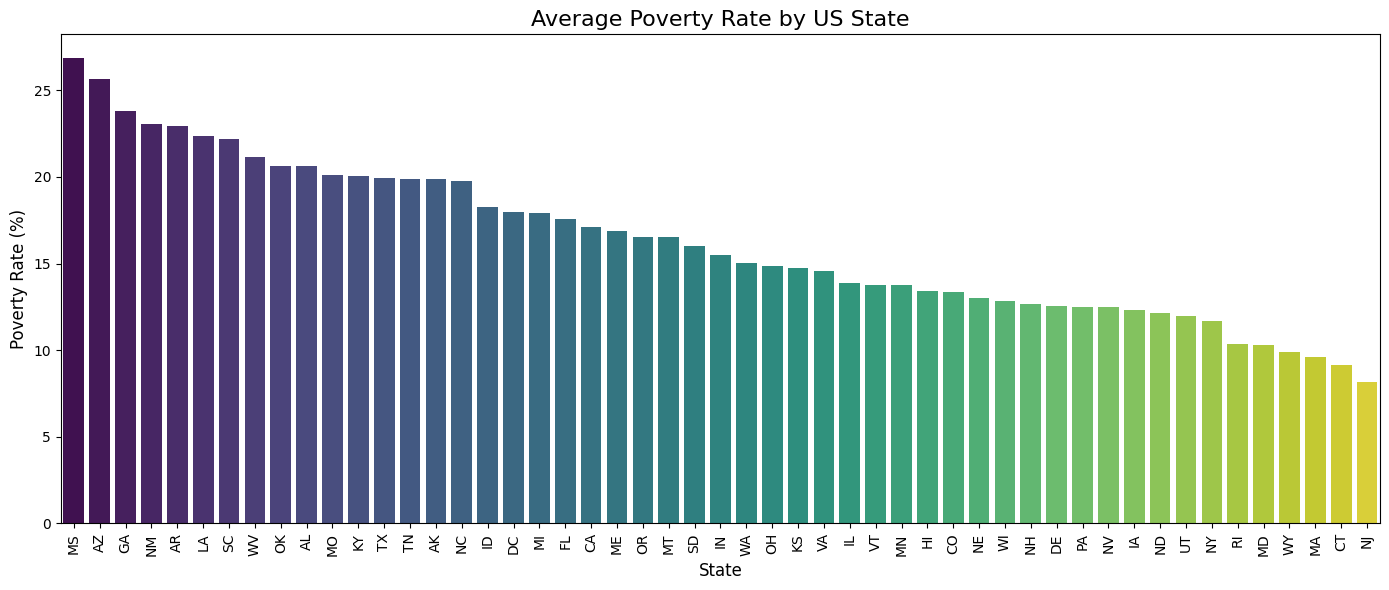

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df_poverty = pd.read_csv("Pct_People_Below_Poverty_Level.csv", encoding="windows-1252")

# Clean the poverty_rate column (coerce non-numeric characters like '-' to NaN)
df_poverty['poverty_rate'] = pd.to_numeric(df_poverty['poverty_rate'], errors='coerce')

# Group by state, calculate the mean poverty rate, and sort descending
state_poverty = df_poverty.groupby('Geographic Area')['poverty_rate'].mean().sort_values(ascending=False)

# Identify the states with the highest and lowest poverty rates
highest_state = state_poverty.index[0]
highest_rate = state_poverty.iloc[0]
lowest_state = state_poverty.index[-1]
lowest_rate = state_poverty.iloc[-1]

print(f"State with Highest Poverty Rate: {highest_state} ({highest_rate:.2f}%)")
print(f"State with Lowest Poverty Rate: {lowest_state} ({lowest_rate:.2f}%)")

# Create the Bar Chart
plt.figure(figsize=(14, 6))
sns.barplot(x=state_poverty.index, y=state_poverty.values, palette='viridis')

plt.title('Average Poverty Rate by US State', fontsize=16)
plt.xlabel('State', fontsize=12)
plt.ylabel('Poverty Rate (%)', fontsize=12)
plt.xticks(rotation=90) # Rotate x-axis labels so they don't overlap
plt.tight_layout()

# Save the figure or show it
plt.savefig('poverty_by_state.png')
# plt.show()

# Chart the High School Graduation Rate by US State

/tmp/ipykernel_795/4115522681.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_hs.index, y=state_hs.values, palette='magma')


State with Lowest HS Graduation Rate: TX (75.69%)
State with Highest HS Graduation Rate: MA (92.40%)


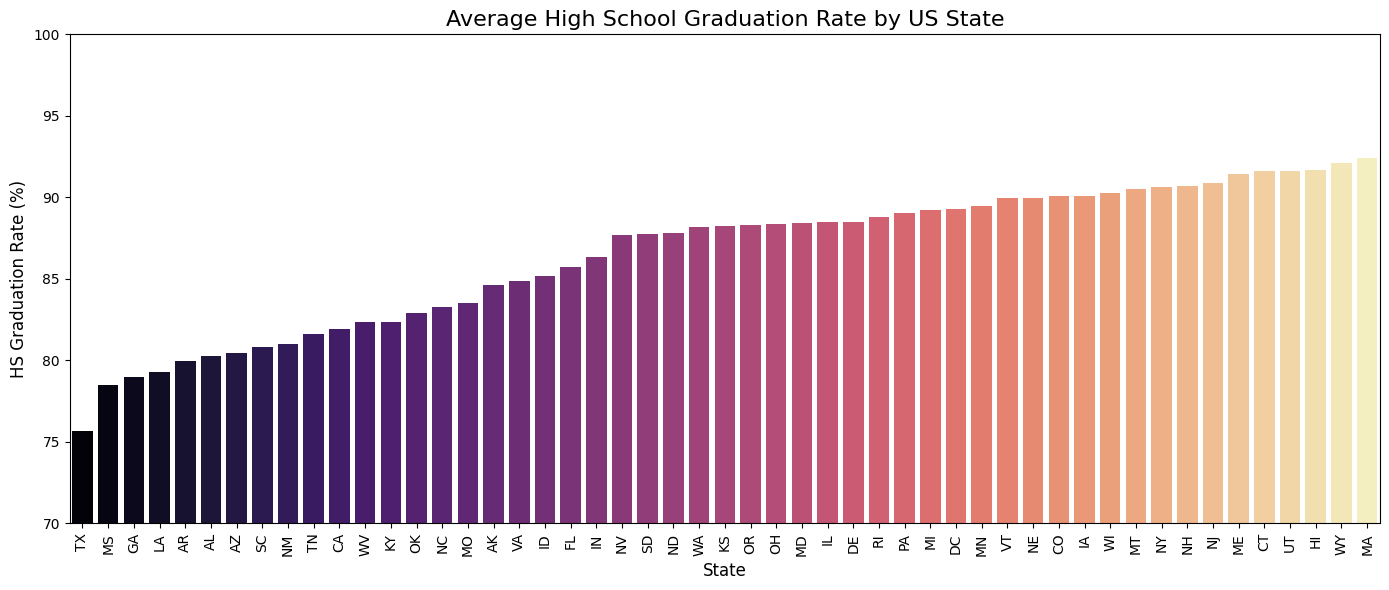

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
df_hs = pd.read_csv("Pct_Over_25_Completed_High_School.csv", encoding="windows-1252")

# 2. Clean the data (convert non-numeric string values like '-' to NaN)
df_hs['percent_completed_hs'] = pd.to_numeric(df_hs['percent_completed_hs'], errors='coerce')

# 3. Group by state, calculate the mean high school completion rate, and sort ascending
state_hs = df_hs.groupby('Geographic Area')['percent_completed_hs'].mean().sort_values(ascending=True)

# 4. Create the Bar Chart
plt.figure(figsize=(14, 6))
sns.barplot(x=state_hs.index, y=state_hs.values, palette='magma')

plt.title('Average High School Graduation Rate by US State', fontsize=16)
plt.xlabel('State', fontsize=12)
plt.ylabel('HS Graduation Rate (%)', fontsize=12)
plt.xticks(rotation=90)
plt.ylim(70, 100) # Zooming in on the y-axis (70% to 100%) to better highlight the differences between states
plt.tight_layout()

# Save the figure
plt.savefig('hs_by_state.png')

# 5. Extract Lowest and Highest
print(f"State with Lowest HS Graduation Rate: {state_hs.index[0]} ({state_hs.iloc[0]:.2f}%)")
print(f"State with Highest HS Graduation Rate: {state_hs.index[-1]} ({state_hs.iloc[-1]:.2f}%)")

# Visualise the Relationship between Poverty Rates and High School Graduation Rates

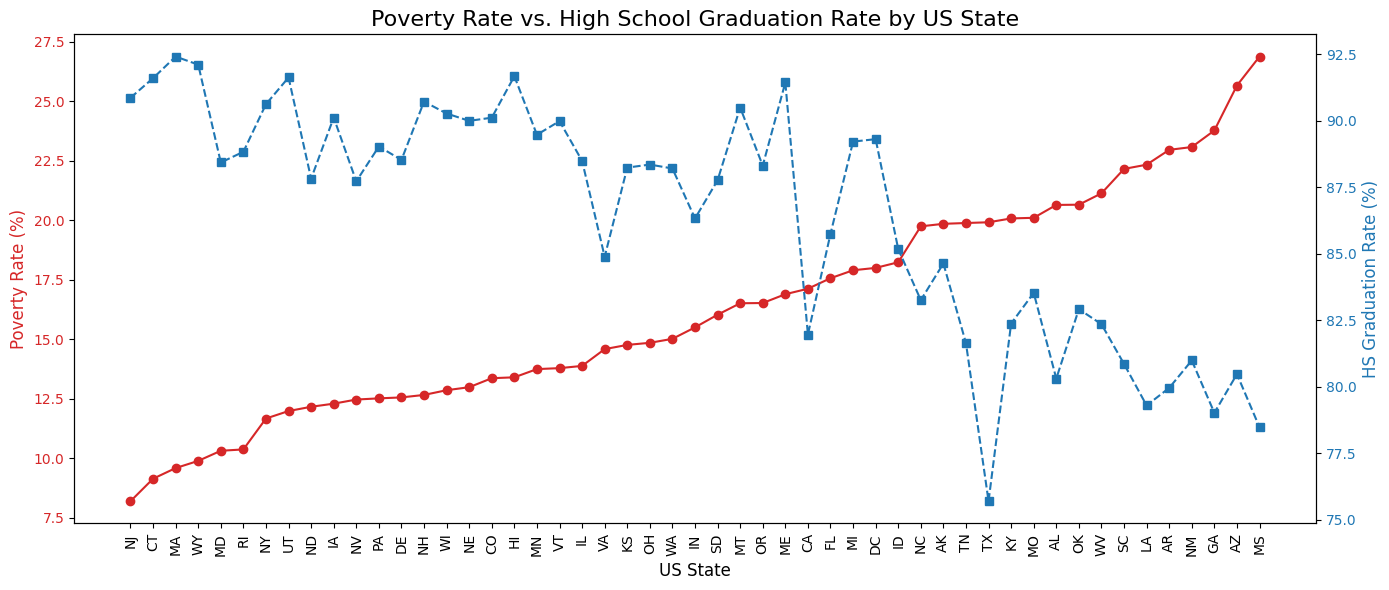

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load Data
df_poverty = pd.read_csv("Pct_People_Below_Poverty_Level.csv", encoding="windows-1252")
df_hs = pd.read_csv("Pct_Over_25_Completed_High_School.csv", encoding="windows-1252")

# 2. Clean Data (convert strings to numeric, coerce '-' to NaN)
df_poverty['poverty_rate'] = pd.to_numeric(df_poverty['poverty_rate'], errors='coerce')
df_hs['percent_completed_hs'] = pd.to_numeric(df_hs['percent_completed_hs'], errors='coerce')

# 3. Group by State and Calculate Mean
state_poverty = df_poverty.groupby('Geographic Area')['poverty_rate'].mean()
state_hs = df_hs.groupby('Geographic Area')['percent_completed_hs'].mean()

# 4. Combine into a single DataFrame
merged_df = pd.DataFrame({'Poverty Rate': state_poverty, 'HS Grad Rate': state_hs})

# 5. Sort by Poverty Rate to make the trend visible
merged_df = merged_df.sort_values(by='Poverty Rate')

# 6. Plotting with Two Y-Axes
fig, ax1 = plt.subplots(figsize=(14, 6))

# First Y-Axis (Poverty Rate)
color1 = 'tab:red'
ax1.set_xlabel('US State', fontsize=12)
ax1.set_ylabel('Poverty Rate (%)', color=color1, fontsize=12)
ax1.plot(merged_df.index, merged_df['Poverty Rate'], color=color1, marker='o', label='Poverty Rate')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.tick_params(axis='x', rotation=90) # Rotate x-axis labels

# Second Y-Axis (High School Graduation Rate)
ax2 = ax1.twinx()  # Instantiate a second axes that shares the same x-axis

color2 = 'tab:blue'
ax2.set_ylabel('HS Graduation Rate (%)', color=color2, fontsize=12)
ax2.plot(merged_df.index, merged_df['HS Grad Rate'], color=color2, marker='s', linestyle='--', label='HS Grad Rate')
ax2.tick_params(axis='y', labelcolor=color2)

# Title and Layout
plt.title('Poverty Rate vs. High School Graduation Rate by US State', fontsize=16)
fig.tight_layout()

# Save the figure
plt.savefig('poverty_vs_hs_line.png')
# plt.show()

#### Now use a Seaborn .jointplot() with a Kernel Density Estimate (KDE) and/or scatter plot to visualise the same relationship

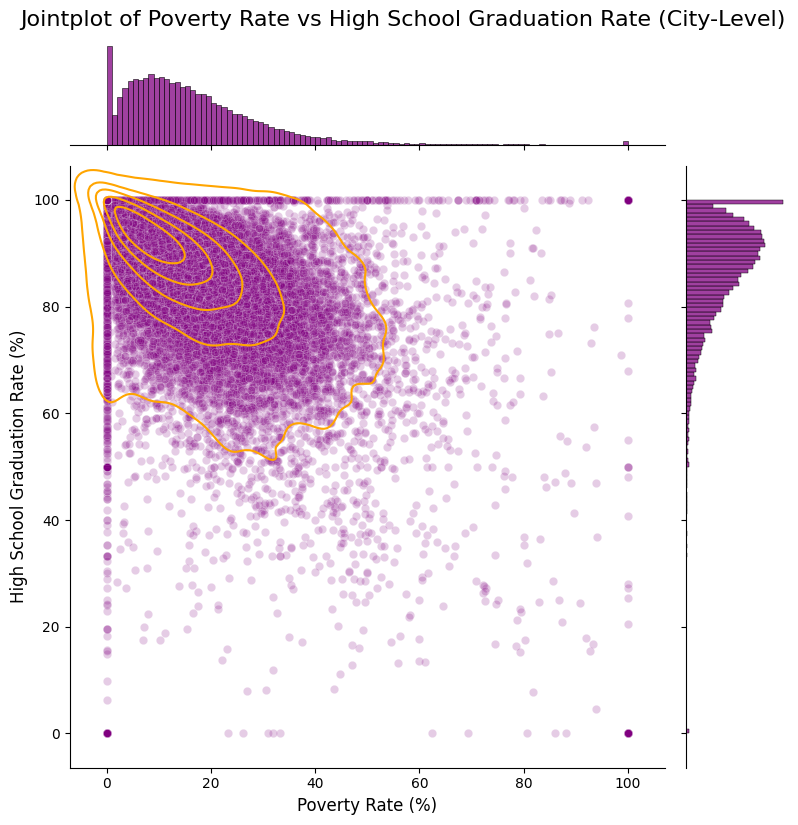

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data
df_poverty = pd.read_csv("Pct_People_Below_Poverty_Level.csv", encoding="windows-1252")
df_hs = pd.read_csv("Pct_Over_25_Completed_High_School.csv", encoding="windows-1252")

# 2. Clean Data (convert strings to numeric, force errors like '-' to NaN)
df_poverty['poverty_rate'] = pd.to_numeric(df_poverty['poverty_rate'], errors='coerce')
df_hs['percent_completed_hs'] = pd.to_numeric(df_hs['percent_completed_hs'], errors='coerce')

# 3. Merge data at the city level for a denser, more informative KDE/Scatter plot
merged_city_df = pd.merge(df_poverty, df_hs, on=['Geographic Area', 'City'], how='inner')

# Drop any rows where we couldn't get a valid number
merged_city_df.dropna(inplace=True)

# 4. Create the Jointplot
# We will use a scatter plot as the base and overlay a KDE plot to show density
g = sns.jointplot(
    data=merged_city_df,
    x='poverty_rate',
    y='percent_completed_hs',
    kind='scatter',
    alpha=0.2, # Make points transparent to see density better
    color='purple',
    height=8
)

# 5. Overlay KDE to show the 2D density distribution
g.plot_joint(sns.kdeplot, color='orange', zorder=10, levels=6)

# Add labels and a title
g.set_axis_labels('Poverty Rate (%)', 'High School Graduation Rate (%)', fontsize=12)
g.fig.suptitle('Jointplot of Poverty Rate vs High School Graduation Rate (City-Level)', y=1.02, fontsize=16)

# Save the plot
plt.savefig('jointplot_poverty_hs.png', bbox_inches='tight')
# plt.show()

#### Seaborn's `.lmplot()` or `.regplot()` to show a linear regression between the poverty ratio and the high school graduation ratio.

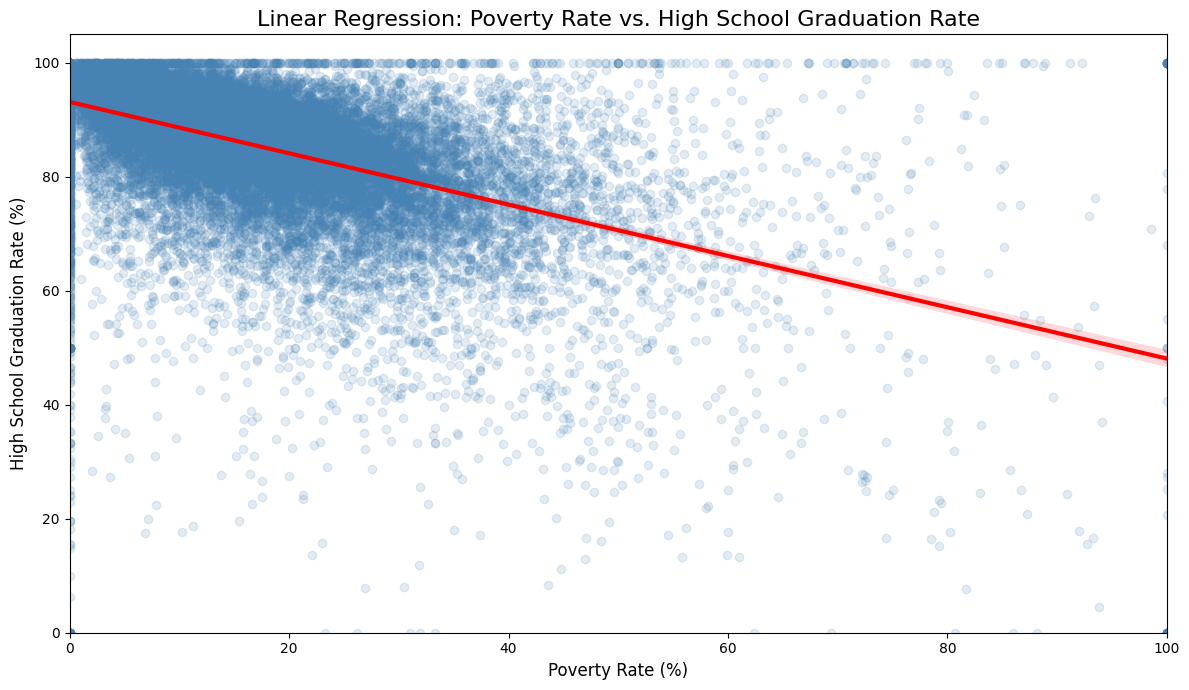

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data
df_poverty = pd.read_csv("Pct_People_Below_Poverty_Level.csv", encoding="windows-1252")
df_hs = pd.read_csv("Pct_Over_25_Completed_High_School.csv", encoding="windows-1252")

# 2. Clean Data (coerce non-numeric strings to NaN)
df_poverty['poverty_rate'] = pd.to_numeric(df_poverty['poverty_rate'], errors='coerce')
df_hs['percent_completed_hs'] = pd.to_numeric(df_hs['percent_completed_hs'], errors='coerce')

# 3. Merge Data at the City level and drop empty rows
merged_df = pd.merge(df_poverty, df_hs, on=['Geographic Area', 'City'], how='inner').dropna()

# 4. Create the Linear Regression Plot
plt.figure(figsize=(12, 7))

sns.regplot(
    data=merged_df,
    x='poverty_rate',
    y='percent_completed_hs',
    scatter_kws={'alpha': 0.15, 'color': 'steelblue'}, # Make scatter points semi-transparent
    line_kws={'color': 'red', 'linewidth': 3}          # Make the regression line thick and red
)

# 5. Add Titles and Labels
plt.title('Linear Regression: Poverty Rate vs. High School Graduation Rate', fontsize=16)
plt.xlabel('Poverty Rate (%)', fontsize=12)
plt.ylabel('High School Graduation Rate (%)', fontsize=12)

# Cap the axes for a cleaner look
plt.xlim(0, 100)
plt.ylim(0, 105)

plt.tight_layout()

# Save the plot
plt.savefig('regplot_poverty_hs.png')
# plt.show()

# A Bar Chart with Subsections Showing the Racial Makeup of Each US State


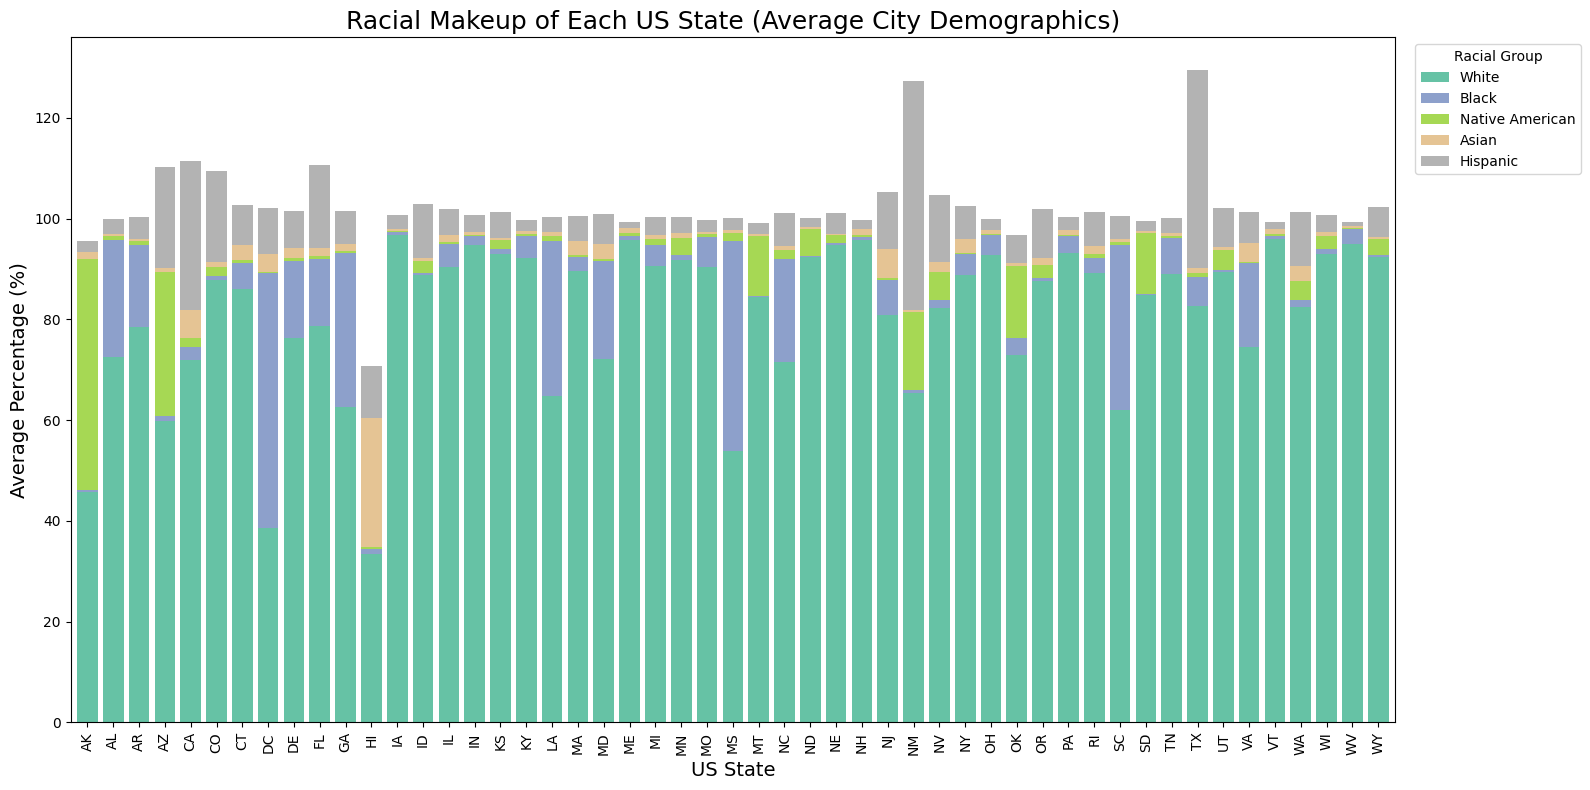

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load Data
df_race = pd.read_csv("Share_of_Race_By_City.csv", encoding="windows-1252")

# 2. Clean Data (convert string percentages to numeric, replacing invalid strings with NaN)
race_columns = ['share_white', 'share_black', 'share_native_american', 'share_asian', 'share_hispanic']
for col in race_columns:
    df_race[col] = pd.to_numeric(df_race[col], errors='coerce')

# 3. Group by State and calculate the mean percentage for each racial group
state_race_avg = df_race.groupby('Geographic area')[race_columns].mean()

# 4. Create a Stacked Bar Chart
fig, ax = plt.subplots(figsize=(16, 8))

# Using pandas built-in plotting for stacked bar charts
state_race_avg.plot(kind='bar', stacked=True, ax=ax, colormap='Set2', width=0.8)

# 5. Add Titles and Labels
plt.title('Racial Makeup of Each US State (Average City Demographics)', fontsize=18)
plt.xlabel('US State', fontsize=14)
plt.ylabel('Average Percentage (%)', fontsize=14)

# Format the legend to look clean and be placed outside the chart
plt.legend(
    title='Racial Group',
    labels=['White', 'Black', 'Native American', 'Asian', 'Hispanic'],
    bbox_to_anchor=(1.01, 1),
    loc='upper left'
)

plt.xticks(rotation=90)
plt.tight_layout()

# Save the plot
plt.savefig('stacked_bar_race_by_state.png')
# plt.show()

# Donut Chart by of People Killed by Race

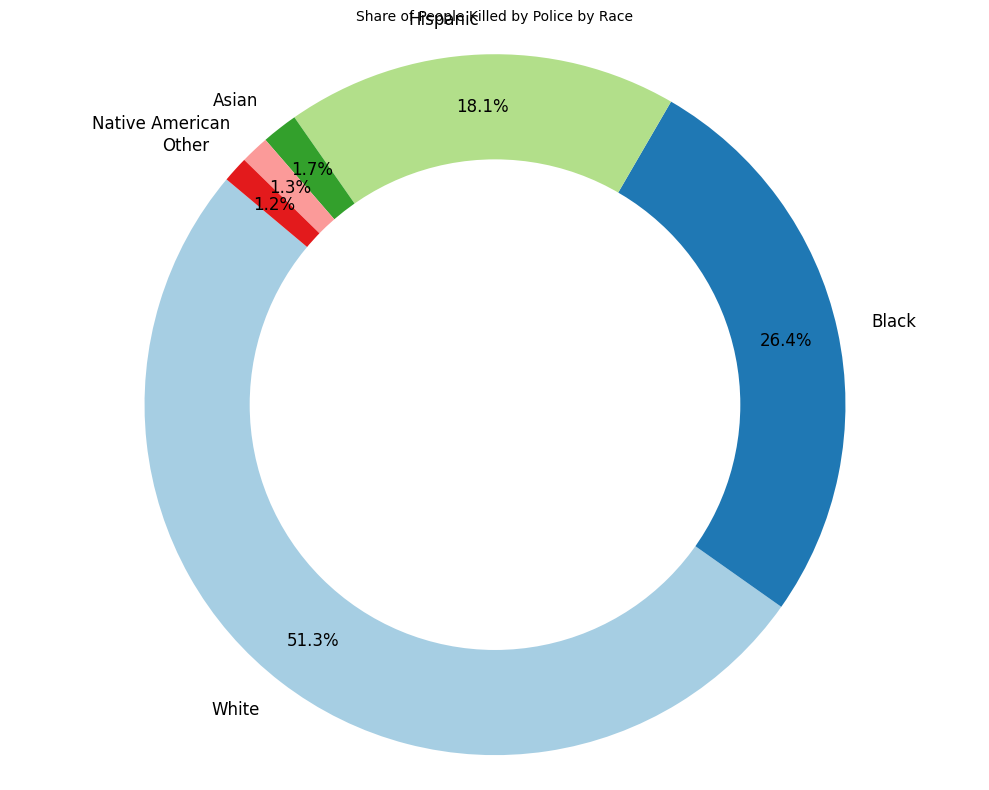

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load Data
df_police = pd.read_csv("Deaths_by_Police_US.csv", encoding="windows-1252")

# 2. Get value counts of people killed by race
# We drop NaN values in the race column just for this chart to ensure clean percentages
race_counts = df_police['race'].dropna().value_counts()

# Replace race codes with actual names for a better legend
race_labels = {
    'W': 'White',
    'B': 'Black',
    'H': 'Hispanic',
    'A': 'Asian',
    'N': 'Native American',
    'O': 'Other'
}
labels = [race_labels.get(code, code) for code in race_counts.index]

# 3. Create a Donut Chart
fig, ax = plt.subplots(figsize=(10, 8))

# Plot the pie chart
wedges, texts, autotexts = ax.pie(
    race_counts.values,
    labels=labels,
    autopct='%1.1f%%',
    startangle=140,
    colors=plt.cm.Paired.colors,
    pctdistance=0.85, # Move percentage text slightly outwards towards the rim
    textprops={'fontsize': 12}
)

# Draw a white circle in the center to create the "donut" shape
center_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(center_circle)

# Equal aspect ratio ensures that pie is drawn as a perfect circle
ax.axis('equal')

# Add a title
plt.title('Share of People Killed by Police by Race', fontsize=10,)
plt.tight_layout()

# Save the plot
plt.savefig('donut_race.png')
# plt.show()

# Comparing the Total Number of Deaths of Men and Women

/tmp/ipykernel_795/1024030680.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=gender_counts.index, y=gender_counts.values, palette=['#1f77b4', '#ff7f0e'])
/tmp/ipykernel_795/1024030680.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Male (M)', 'Female (F)'])


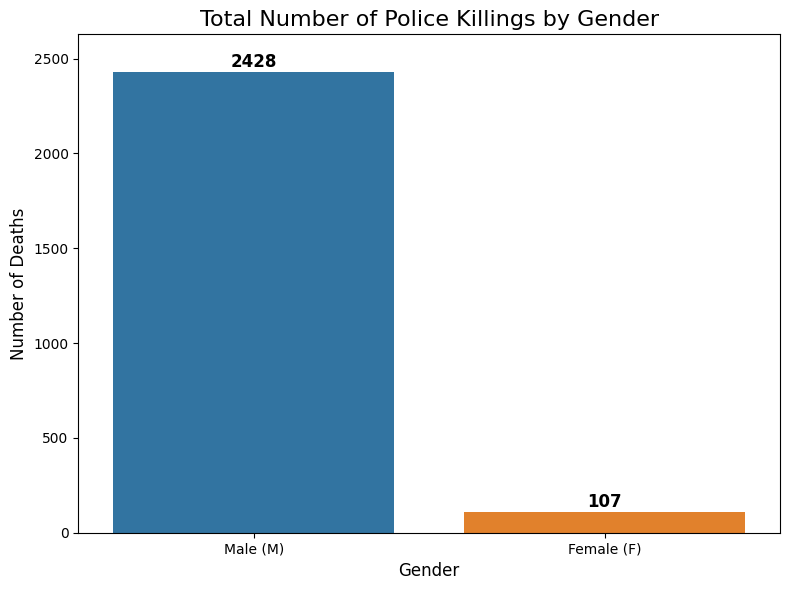

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data
df_fatalities = pd.read_csv("Deaths_by_Police_US.csv", encoding="windows-1252")

# 2. Get value counts for gender
gender_counts = df_fatalities['gender'].value_counts()

# 3. Create a Bar Chart
plt.figure(figsize=(8, 6))

# Plot the bar chart
ax = sns.barplot(x=gender_counts.index, y=gender_counts.values, palette=['#1f77b4', '#ff7f0e'])

# Annotate the exact numbers on top of the bars
for i, count in enumerate(gender_counts.values):
    ax.text(i, count + 30, str(count), ha='center', fontsize=12, fontweight='bold')

# Replace 'M' and 'F' with full words on x-axis
ax.set_xticklabels(['Male (M)', 'Female (F)'])

# Add labels and title
plt.title('Total Number of Police Killings by Gender', fontsize=16)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Number of Deaths', fontsize=12)

# Give a little extra headroom on the y-axis for the text annotations
plt.ylim(0, max(gender_counts.values) + 200)

plt.tight_layout()

# Save the plot
plt.savefig('gender_comparison.png')
# plt.show()

# Box Plot Showing the Age and Manner of Death

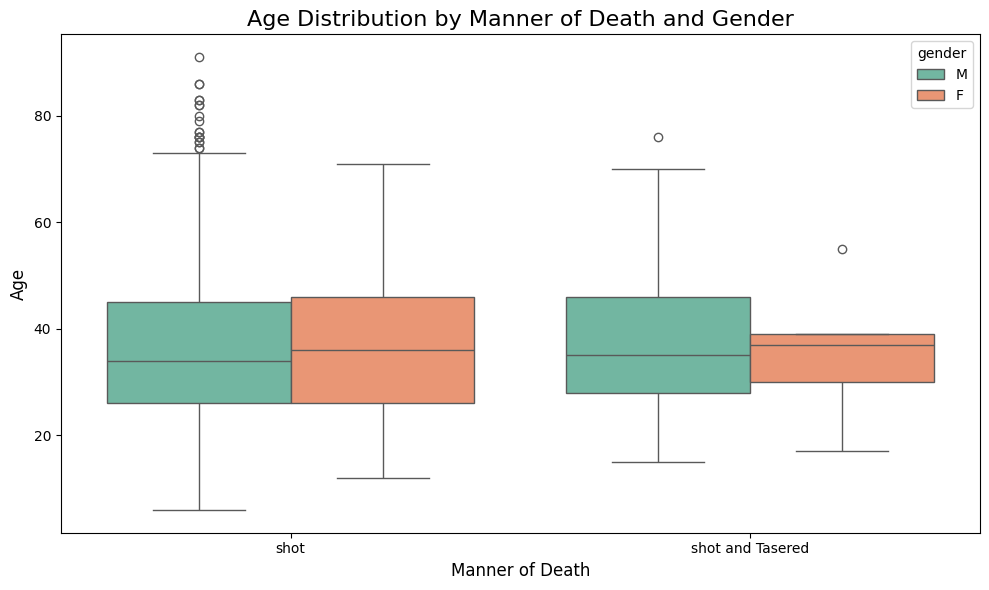

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data
df_fatalities = pd.read_csv("Deaths_by_Police_US.csv", encoding="windows-1252")

# 2. Clean age data (convert to numeric, coercing any odd strings to NaN)
df_fatalities['age'] = pd.to_numeric(df_fatalities['age'], errors='coerce')

# 3. Create Box Plot
plt.figure(figsize=(10, 6))

# sns.boxplot automatically handles the grouping and plotting
sns.boxplot(
    data=df_fatalities,
    x='manner_of_death',
    y='age',
    hue='gender',
    palette='Set2'
)

# 4. Add Titles and Labels
plt.title('Age Distribution by Manner of Death and Gender', fontsize=16)
plt.xlabel('Manner of Death', fontsize=12)
plt.ylabel('Age', fontsize=12)

plt.tight_layout()

# Save the plot
plt.savefig('boxplot_age_manner_gender.png')
# plt.show()

# Were People Armed?

Percentage Armed: 88.3%
Armed with Guns: 1398
Unarmed: 171


/tmp/ipykernel_795/4152584613.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_weapons.values, y=top_weapons.index, palette='Reds_r')


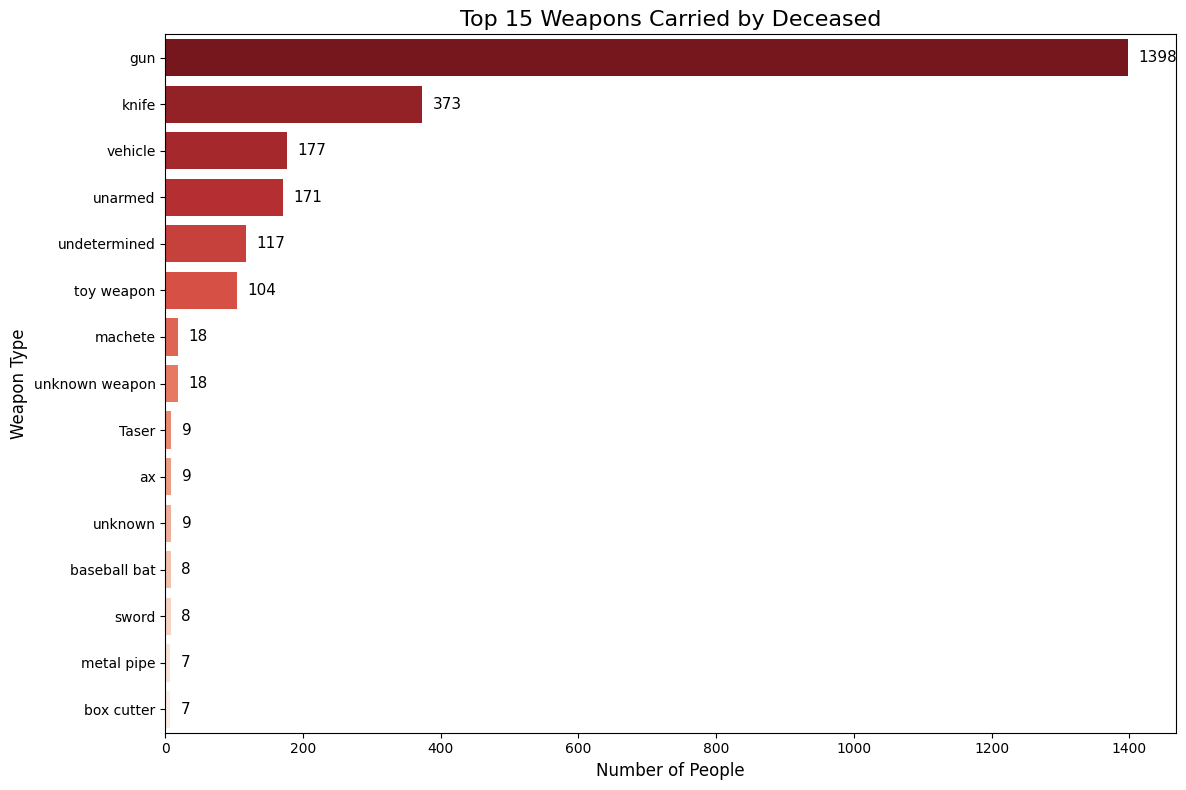

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data
df_police = pd.read_csv("Deaths_by_Police_US.csv", encoding="windows-1252")

# 2. Clean the data (fill missing values in the 'armed' column)
df_police['armed'] = df_police['armed'].fillna('unknown')

# 3. Get the counts for each weapon type
weapon_counts = df_police['armed'].value_counts()

# 4. Extract specific numbers for the analysis
total_cases = len(df_police)
unarmed_cases = weapon_counts.get('unarmed', 0)
gun_cases = weapon_counts.get('gun', 0)

# Calculate how many were definitely armed (Total minus unarmed, unknown, and undetermined)
unknown_undetermined = weapon_counts.get('unknown', 0) + weapon_counts.get('undetermined', 0)
armed_cases = total_cases - unarmed_cases - unknown_undetermined
armed_percentage = (armed_cases / total_cases) * 100

print(f"Percentage Armed: {armed_percentage:.1f}%")
print(f"Armed with Guns: {gun_cases}")
print(f"Unarmed: {unarmed_cases}")

# 5. Create a Horizontal Bar Chart for the Top 15 Weapons
plt.figure(figsize=(12, 8))

# We take the top 15 so the chart isn't overly cluttered with rare 1-off items
top_weapons = weapon_counts.head(15)

sns.barplot(x=top_weapons.values, y=top_weapons.index, palette='Reds_r')

plt.title('Top 15 Weapons Carried by Deceased', fontsize=16)
plt.xlabel('Number of People', fontsize=12)
plt.ylabel('Weapon Type', fontsize=12)

# Annotate the exact numbers next to the bars
for index, value in enumerate(top_weapons.values):
    plt.text(value + 15, index, str(value), va='center', fontsize=11)

plt.tight_layout()

# Save the plot
plt.savefig('weapons_carried.png')
# plt.show()

# How Old Were the People Killed?

Work out what percentage of people killed were under 25 years old.  

In [34]:
import pandas as pd

# Load Data
df_police = pd.read_csv("Deaths_by_Police_US.csv", encoding="windows-1252")

# Clean 'age' column (convert to numeric, replace invalid text with NaN)
df_police['age'] = pd.to_numeric(df_police['age'], errors='coerce')

# Calculate percentages
total_known_ages = df_police['age'].dropna().shape[0]
under_25 = (df_police['age'] < 25).sum()
percentage_under_25 = (under_25 / total_known_ages) * 100

print(f"Percentage of people under 25: {percentage_under_25:.2f}%")


Percentage of people under 25: 18.31%


Histogram and KDE plot that shows the distribution of ages of the people killed by police.

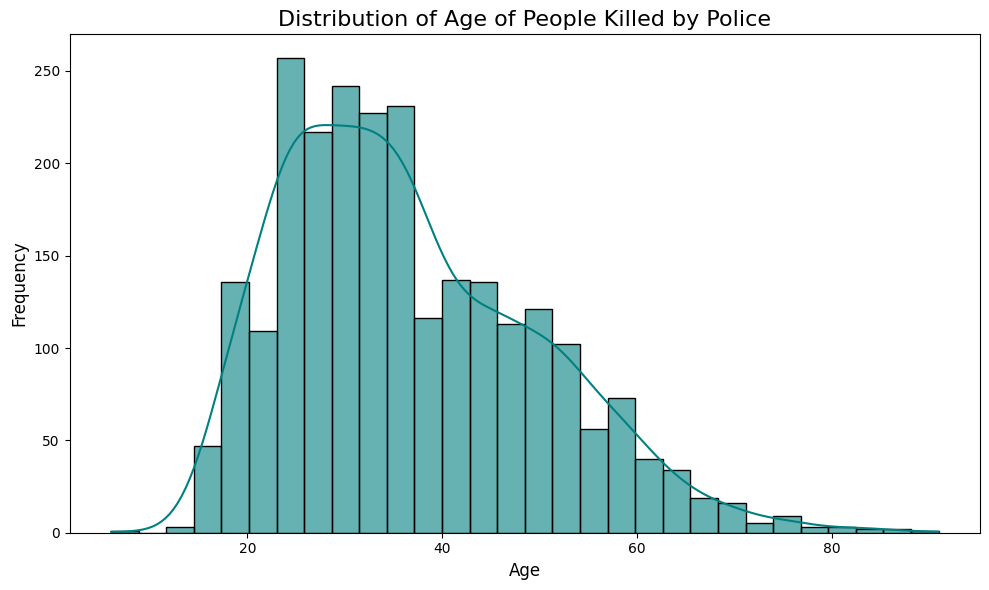

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Plot Histogram and KDE
sns.histplot(data=df_police, x='age', kde=True, bins=30, color='teal', alpha=0.6)

plt.title('Distribution of Age of People Killed by Police', fontsize=16)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()

# Save the plot
plt.savefig('age_histogram_kde.png')
# plt.show()

KDE plot for each race to check difference between the distributions

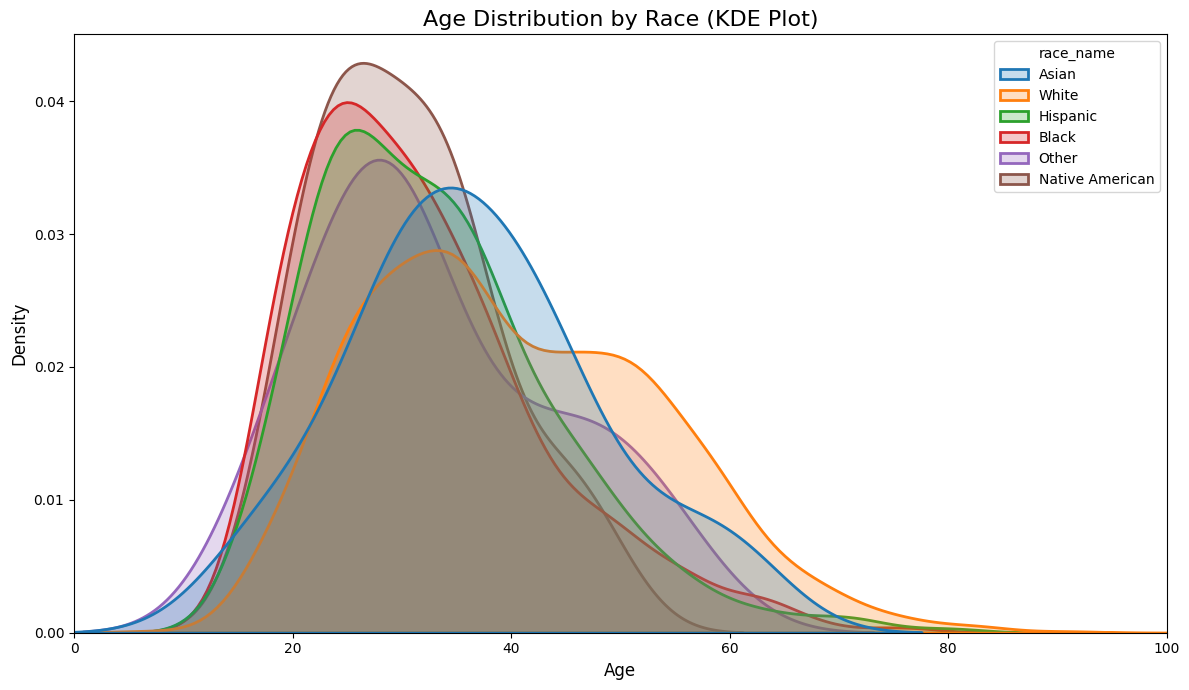

In [31]:
plt.figure(figsize=(12, 7))

# Replace single-letter race codes with full words for a better legend
race_labels = {'W': 'White', 'B': 'Black', 'H': 'Hispanic', 'A': 'Asian', 'N': 'Native American', 'O': 'Other'}
df_police['race_name'] = df_police['race'].map(race_labels)

# Plot KDE separated by 'race_name'
sns.kdeplot(
    data=df_police.dropna(subset=['age', 'race_name']),
    x='age',
    hue='race_name',
    common_norm=False, # Evaluates each curve independently so they all have the same area under the curve
    fill=True,
    alpha=0.25,
    linewidth=2
)

plt.title('Age Distribution by Race (KDE Plot)', fontsize=16)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.xlim(0, 100) # Keep within realistic age limits
plt.tight_layout()

# Save the plot
plt.savefig('age_kde_by_race.png')
# plt.show()

# Race of People Killed

/tmp/ipykernel_795/519136523.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=race_counts.index, y=race_counts.values, palette='viridis')


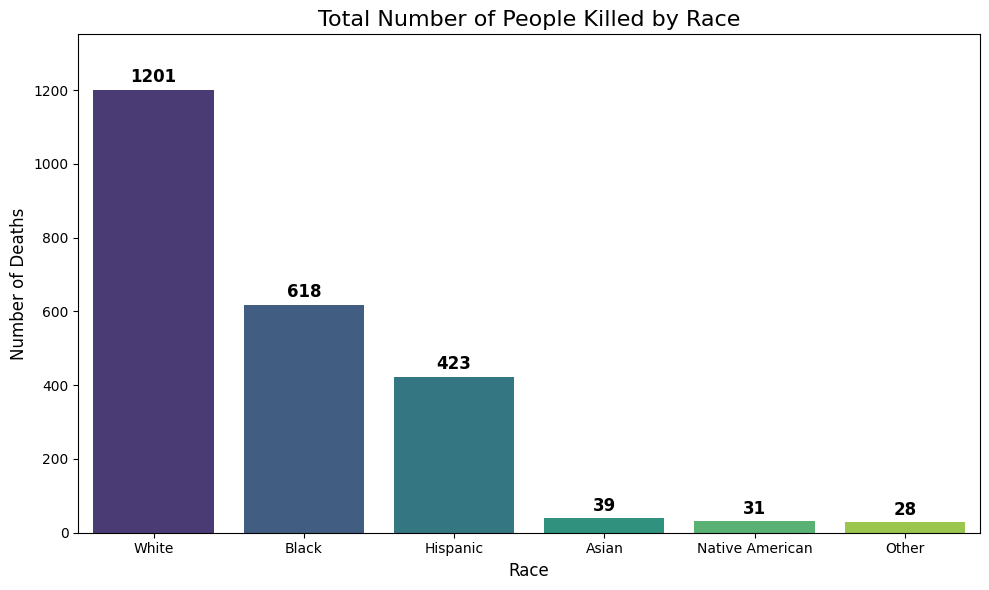

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data
df_police = pd.read_csv("Deaths_by_Police_US.csv", encoding="windows-1252")

# 2. Get value counts for race (dropping NaNs for accurate counts)
race_counts = df_police['race'].dropna().value_counts()

# Replace race codes with actual names for the x-axis labels
race_labels = {
    'W': 'White',
    'B': 'Black',
    'H': 'Hispanic',
    'A': 'Asian',
    'N': 'Native American',
    'O': 'Other'
}
race_counts.index = race_counts.index.map(lambda x: race_labels.get(x, x))

# 3. Create a Bar Chart
plt.figure(figsize=(10, 6))

# Plot the bar chart
ax = sns.barplot(x=race_counts.index, y=race_counts.values, palette='viridis')

# Annotate the exact numbers on top of the bars
for i, count in enumerate(race_counts.values):
    ax.text(i, count + 20, str(count), ha='center', fontsize=12, fontweight='bold')

# Add labels and title
plt.title('Total Number of People Killed by Race', fontsize=16)
plt.xlabel('Race', fontsize=12)
plt.ylabel('Number of Deaths', fontsize=12)

# Give a little extra headroom on the y-axis for the text annotations
plt.ylim(0, race_counts.max() + 150)

plt.tight_layout()

# Save the plot
plt.savefig('total_killed_by_race.png')
# plt.show()

# Mental Illness and Police Killings

In [36]:
import pandas as pd

# 1. Load Data
df_police = pd.read_csv("Deaths_by_Police_US.csv", encoding="windows-1252")

# 2. Calculate the value counts as percentages
mental_illness_percentages = df_police['signs_of_mental_illness'].value_counts(normalize=True) * 100
mental_illness_counts = df_police['signs_of_mental_illness'].value_counts()

print("Percentage Breakdown:")
print(mental_illness_percentages)

print("\nRaw Counts:")
print(mental_illness_counts)

Percentage Breakdown:
signs_of_mental_illness
False   75.03
True    24.97
Name: proportion, dtype: float64

Raw Counts:
signs_of_mental_illness
False    1902
True      633
Name: count, dtype: int64


**Rank Top 10 Cities**

/tmp/ipykernel_795/2910750569.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_cities.index, y=top_10_cities.values, palette='plasma')


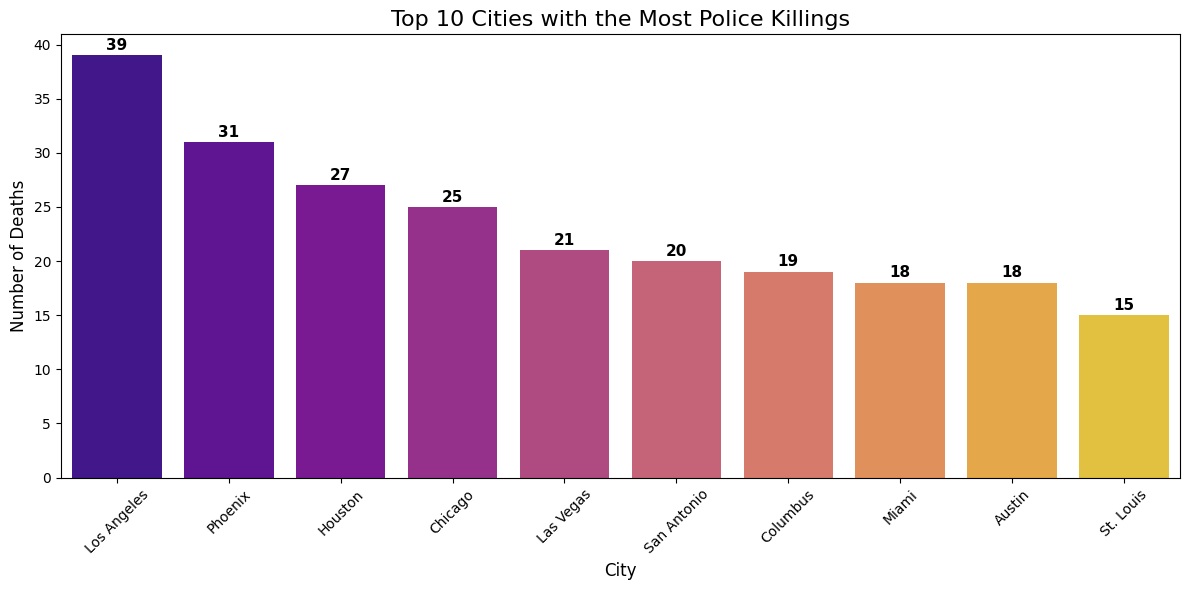

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data
df_police = pd.read_csv("Deaths_by_Police_US.csv", encoding="windows-1252")

# 2. Count occurrences of each city
city_counts = df_police['city'].value_counts()

# 3. Select the top 10 cities
top_10_cities = city_counts.head(10)

# 4. Create a Bar Chart
plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_cities.index, y=top_10_cities.values, palette='plasma')

# Annotate the exact numbers on top of the bars
for i, count in enumerate(top_10_cities.values):
    plt.text(i, count + 0.5, str(count), ha='center', fontsize=11, fontweight='bold')

plt.title('Top 10 Cities with the Most Police Killings', fontsize=16)
plt.xlabel('City', fontsize=12)
plt.ylabel('Number of Deaths', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()

# Save the plot
plt.savefig('top_10_cities.png')
# plt.show()

# Rate of Death by Race

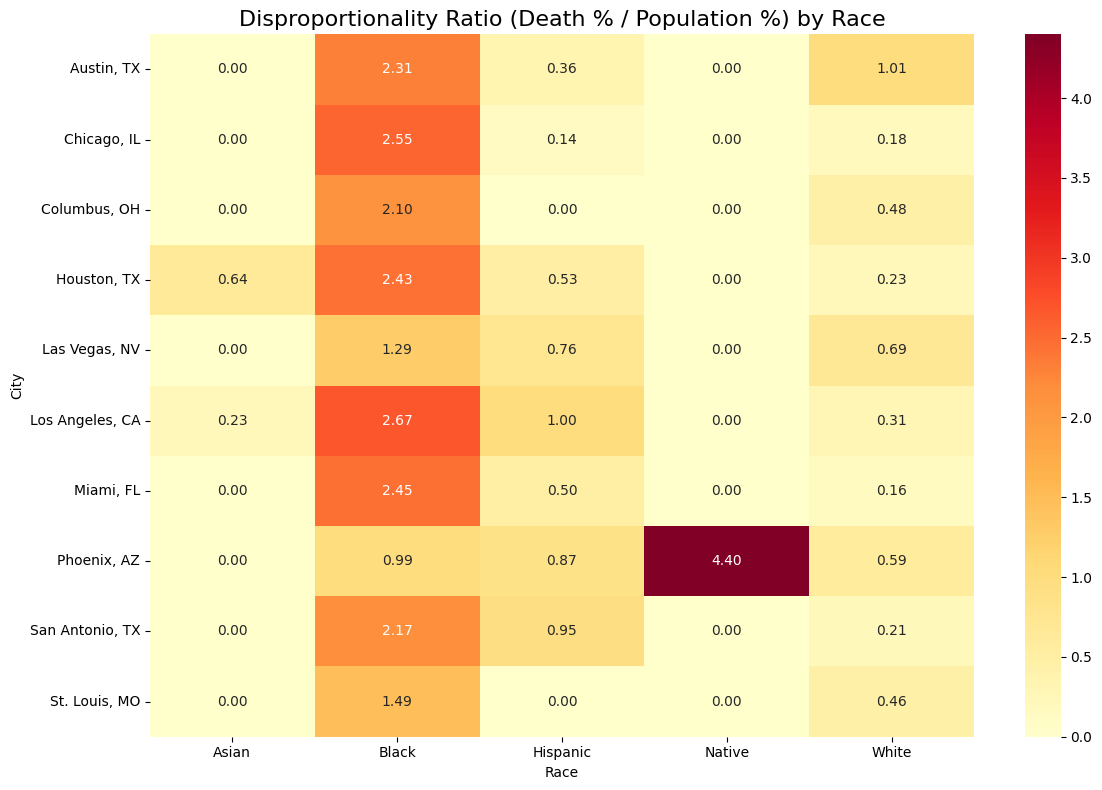

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load and clean datasets
df_deaths = pd.read_csv("Deaths_by_Police_US.csv", encoding="windows-1252")
df_race_share = pd.read_csv("Share_of_Race_By_City.csv", encoding="windows-1252")

# Convert population shares to numeric
race_cols = ['share_white', 'share_black', 'share_native_american', 'share_asian', 'share_hispanic']
for col in race_cols:
    df_race_share[col] = pd.to_numeric(df_race_share[col], errors='coerce')

# Clean city names in demographics to match the deaths dataset
df_race_share['city_clean'] = df_race_share['City'].str.replace(' city| town| CDP| village', '', regex=True)

# 2. Identify Top 10 Cities by number of killings
top_10_locs = df_deaths.groupby(['city', 'state']).size().sort_values(ascending=False).head(10).index.tolist()

# 3. Calculate the Disproportionality Ratio
results = []
race_mapping = {'W': 'share_white', 'B': 'share_black', 'N': 'share_native_american', 'A': 'share_asian', 'H': 'share_hispanic'}

for city, state in top_10_locs:
    city_pop = df_race_share[(df_race_share['city_clean'] == city) & (df_race_share['Geographic area'] == state)]
    if not city_pop.empty:
        pop_shares = city_pop.iloc[0][race_cols].to_dict()
        city_deaths = df_deaths[(df_deaths['city'] == city) & (df_deaths['state'] == state)]
        total_city_deaths = len(city_deaths)
        death_counts = city_deaths['race'].value_counts()

        for code, col in race_mapping.items():
            p_share = pop_shares.get(col, 0)
            d_count = death_counts.get(code, 0)
            d_share = (d_count / total_city_deaths) * 100 if total_city_deaths > 0 else 0
            # Calculate Ratio (Death % / Pop %)
            ratio = d_share / p_share if p_share > 0 else 0
            results.append({'City': f"{city}, {state}", 'Race': col.split('_')[1].capitalize(), 'Ratio': ratio})

# 4. Visualize the results
df_results = pd.DataFrame(results)
pivot_df = df_results.pivot(index='City', columns='Race', values='Ratio')

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_df, annot=True, cmap='YlOrRd', fmt=".2f")
plt.title('Disproportionality Ratio (Death % / Population %) by Race', fontsize=16)
plt.tight_layout()
plt.savefig('disproportionality_heatmap.png')

# A Choropleth Map of Police Killings by US State

/tmp/ipykernel_795/2506956079.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_killings.index, y=state_killings.values, palette='Reds_r')


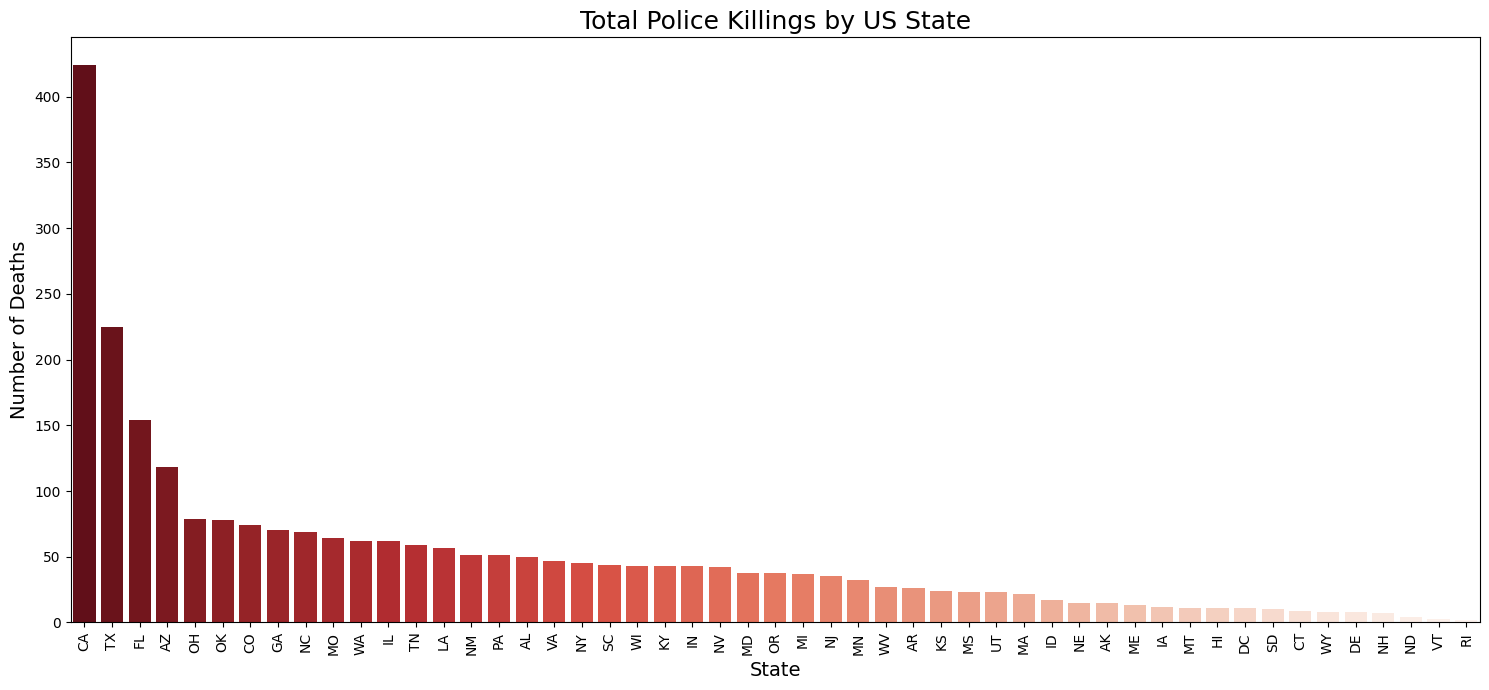

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the data
df_police = pd.read_csv("Deaths_by_Police_US.csv", encoding="windows-1252")

# 2. Count killings by state and sort
state_killings = df_police['state'].value_counts()

# 3. Plot the data
plt.figure(figsize=(15, 7))
sns.barplot(x=state_killings.index, y=state_killings.values, palette='Reds_r')
plt.title('Total Police Killings by US State', fontsize=18)
plt.xlabel('State', fontsize=14)
plt.ylabel('Number of Deaths', fontsize=14)
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('state_killings_ranking.png')

# Number of Police Killings Over Time

/tmp/ipykernel_795/3375282819.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_police['date'] = pd.to_datetime(df_police['date'], dayfirst=True)
/tmp/ipykernel_795/3375282819.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_killings = df_police.set_index('date').resample('M').size()


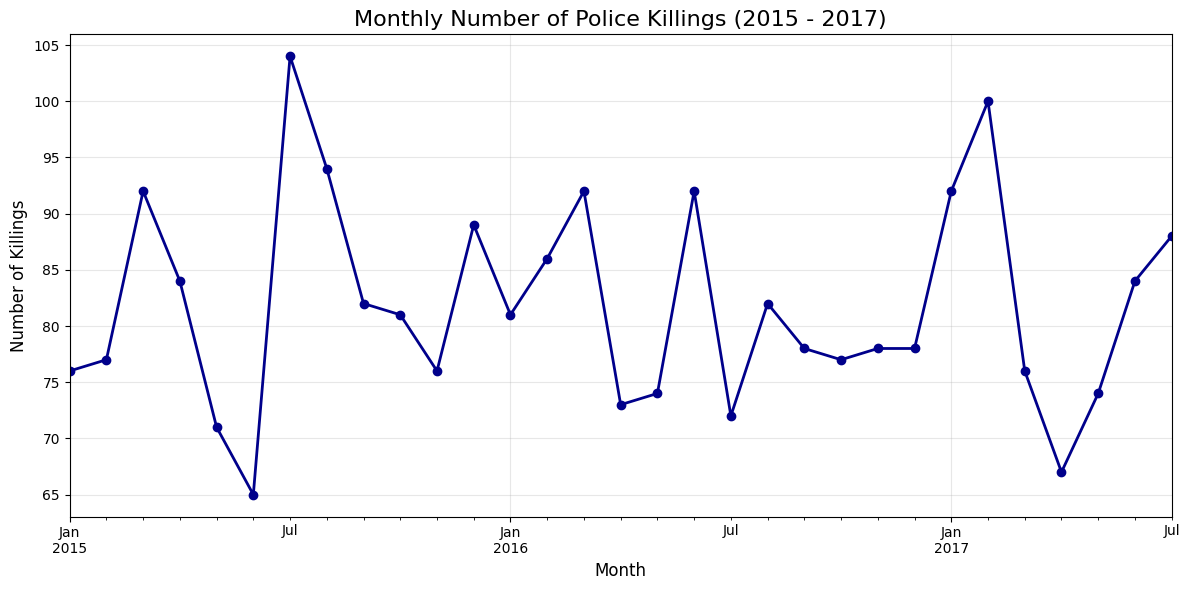

In [40]:
# 1. Convert date column to datetime objects
# Note: The format is Day/Month/Year
df_police['date'] = pd.to_datetime(df_police['date'], dayfirst=True)

# 2. Resample the data to count incidents by Month
monthly_killings = df_police.set_index('date').resample('M').size()

# 3. Create a line chart
plt.figure(figsize=(12, 6))
monthly_killings.plot(color='darkblue', marker='o', linestyle='-', linewidth=2)
plt.title('Monthly Number of Police Killings (2015 - 2017)', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Killings', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('killings_over_time.png')